# Transistor Count vs. Moore's Law Growth (Filtered Data)

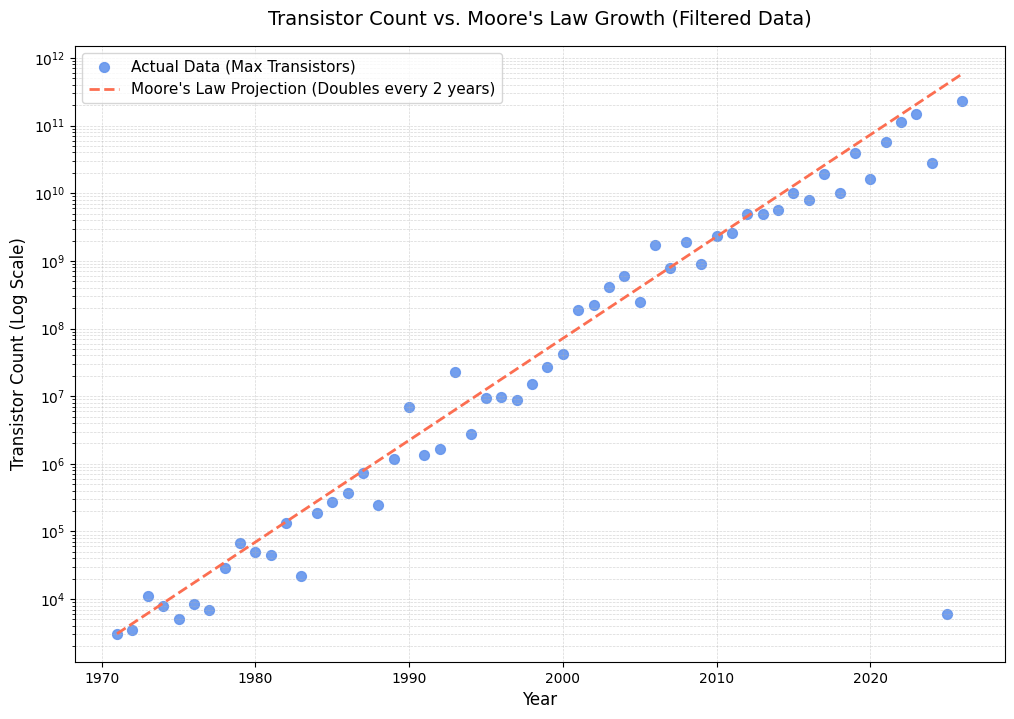

In [4]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("data/filtered.csv")

# 3. Configure the canvas size globally (avoids standard size restrictions)
plt.rcParams["figure.figsize"] = (12, 8)

# 4. Plot actual data using a soft shade of blue ('cornflowerblue') and a plus marker '+'
plt.scatter(
    df["year"],
    df["max_transistors"],
    color="cornflowerblue",
    marker="o",
    s=50,
    alpha=0.9,
    label="Actual Data (Max Transistors)",
)

# 5. Dynamically anchor and calculate Moore's Law Curve
start_year = df["year"].min()
start_count = df[df["year"] == start_year]["max_transistors"].values[0]

# Create a smooth trajectory baseline over the timeline
years_line = np.linspace(start_year, df["year"].max(), 200)
moores_law_counts = start_count * (2 ** ((years_line - start_year) / 2))

# Plot Moore's Law ideal projection
plt.plot(
    years_line,
    moores_law_counts,
    color="#FC6E51",
    linestyle="--",
    linewidth=2,
    label="Moore's Law Projection (Doubles every 2 years)",
)

# 6. Apply Log Scaling, grid lines, and readable typography
plt.yscale("log")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Transistor Count (Log Scale)", fontsize=12)
plt.title(
    "Transistor Count vs. Moore's Law Growth (Filtered Data)",
    fontsize=14,
    pad=15,
)
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(loc="upper left", fontsize=11)


# Transistor Count vs. Growth Projections Featuring 2026 Frontier Chips

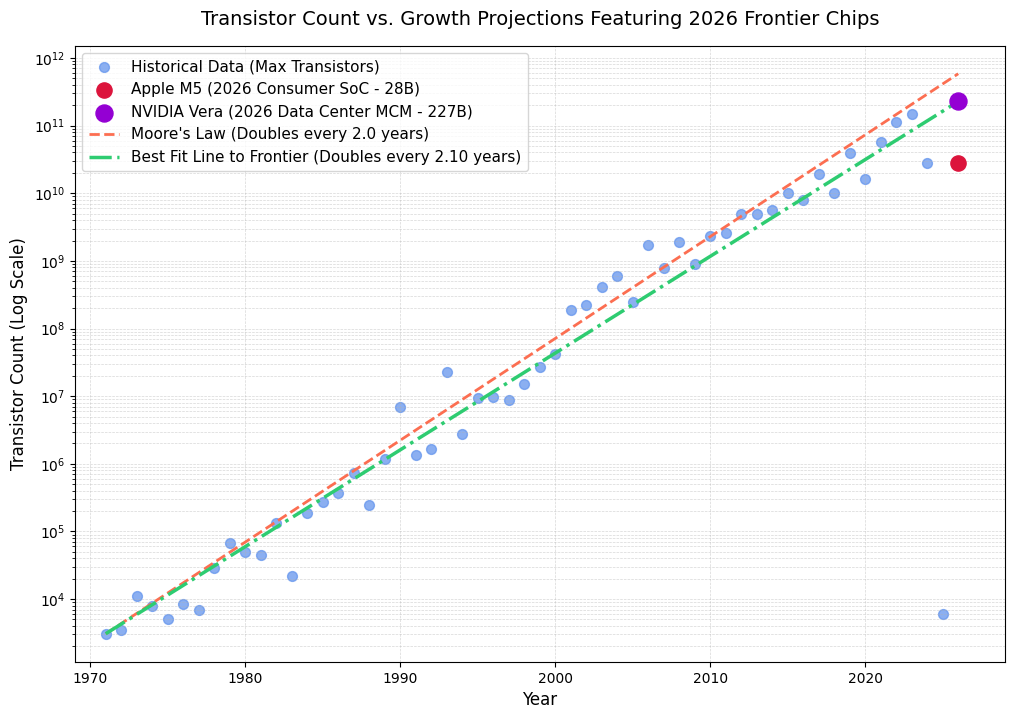

In [2]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load and sort the data chronologically
df = pd.read_csv("data/filtered.csv")

# Clean up any existing 2026 points from the generic dataset to prevent collisions
df = df[df["year"] != 2026]

# Explicitly define our two focal processors from 2026
nvidia_vera_count = 227_000_000_000  # 227 Billion
apple_m5_count = 28_000_000_000       # 28 Billion

# Create entries for the new chips
nvidia_row = pd.DataFrame([{"year": 2026, "max_transistors": nvidia_vera_count}])
apple_row = pd.DataFrame([{"year": 2026, "max_transistors": apple_m5_count}])

# Append the new data to our dataframe
df = pd.concat([df, nvidia_row, apple_row], ignore_index=True)
df = df.sort_values("year")

# 2. Configure the canvas size globally
plt.rcParams["figure.figsize"] = (12, 8)

# 3. Plot standard actual historical data points (excluding our specialized 2026 chips)
historical_df = df[~((df["year"] == 2026) & (df["max_transistors"].isin([nvidia_vera_count, apple_m5_count])))]
plt.scatter(
    historical_df["year"],
    historical_df["max_transistors"],
    color="cornflowerblue",
    marker="o",
    s=50,
    alpha=0.75,
    label="Historical Data (Max Transistors)",
)

# Highlight the Apple M5 point specifically
plt.scatter(
    2026,
    apple_m5_count,
    color="crimson",
    marker="o",
    s=120,
    zorder=5,
    label="Apple M5 (2026 Consumer SoC - 28B)",
)

# Highlight the NVIDIA Vera point specifically
plt.scatter(
    2026,
    nvidia_vera_count,
    color="darkviolet",
    marker="o",
    s=150,
    zorder=5,
    label="NVIDIA Vera (2026 Data Center MCM - 227B)",
)

# 4. Reference Parameters (Calculating best fit against the leading-edge frontier: NVIDIA Vera)
start_year = df["year"].min()
end_year = 2026
start_count = df[df["year"] == start_year]["max_transistors"].values[0]

# Create a smooth timeline array for plotting lines
years_line = np.linspace(start_year, end_year, 200)

# 5. Plot Theoretical Moore's Law Curve (Doubles every 2.0 years)
moores_law_counts = start_count * (2 ** ((years_line - start_year) / 2.0))
plt.plot(
    years_line,
    moores_law_counts,
    color="#FC6E51",
    linestyle="--",
    linewidth=2,
    label="Moore's Law (Doubles every 2.0 years)",
)

# 6. Calculate and Plot Best Fit Curve targeting the frontier scaling line (NVIDIA Vera)
years_diff = end_year - start_year
d_fit = years_diff / np.log2(nvidia_vera_count / start_count)
fit_counts = start_count * (2 ** ((years_line - start_year) / d_fit))

plt.plot(
    years_line,
    fit_counts,
    color="#2ECC71",
    linestyle="-.",
    linewidth=2.5,
    label=f"Best Fit Line to Frontier (Doubles every {d_fit:.2f} years)",
)

# 7. Apply Log Scaling, labels, grid, and legends
plt.yscale("log")
plt.xlim(start_year - 2, end_year + 3) # Give room on the right side for markers
plt.xlabel("Year", fontsize=12)
plt.ylabel("Transistor Count (Log Scale)", fontsize=12)
plt.title(
    "Transistor Count vs. Growth Projections Featuring 2026 Frontier Chips",
    fontsize=14,
    pad=15,
)
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(loc="upper left", fontsize=11)